In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Preparasi Data Awal
**Membaca & Meratakan Data:** Menggabungkan kolom bertingkat (*Multi-Index*) menjadi satu string tunggal.

**Pembersihan String:** Menghapus simbol pengganggu (`"`, `,`, `%`) dan mengubah tipe data menjadi numerik.

**Peramalan Upah 2025:** Memproyeksikan nilai upah menggunakan Regresi Linear Sederhana:
  $$\hat{y} = \beta_0 + \beta_1 X$$
  * **$\hat{y}$**: Nilai hasil prediksi/peramalan upah tahun 2025.
  * **$X$**: Variabel independen waktu (Tahun 2025).
  * **$\beta_0$**: Konstanta (*intercept*).
  * **$\beta_1$**: Koefisien kemiringan tren (*slope*).

In [4]:
# 1. Membaca Data Pusat (Gabungan Baris 1 & 2 sebagai Multi-Index Column)
df_pusat = pd.read_csv('Data_Pusat.csv', header=[0, 1])

# Meratakan nama kolom Multi-Index menjadi satu string (Contoh: "Produksi Padi (ton GKG)_2025")
df_pusat.columns = [
    f"{col[0].strip()}_{col[1].strip()}" if "Unnamed" not in col[1] else col[0].strip()
    for col in df_pusat.columns
]

# Membersihkan karakter string (koma dan persen) pada Data Pusat
for col in df_pusat.columns:
    if col not in ['No.', 'Kabupaten']:
        df_pusat[col] = df_pusat[col].astype(str).str.replace('"', '', regex=False)
        df_pusat[col] = df_pusat[col].astype(str).str.replace(',', '', regex=False)
        df_pusat[col] = df_pusat[col].astype(str).str.replace('%', '', regex=False)
        df_pusat[col] = pd.to_numeric(df_pusat[col], errors='coerce')

# 2. Membaca Data Harga Beras NTT
df_beras = pd.read_csv('Data_HargaBerasNTT.csv')

# Membersihkan data numerik di tabel Beras
for col in df_beras.columns:
    if col != 'Tahun/Bulan':
        df_beras[col] = df_beras[col].astype(str).str.replace('"', '', regex=False)
        df_beras[col] = df_beras[col].astype(str).str.replace(',', '', regex=False)
        df_beras[col] = pd.to_numeric(df_beras[col], errors='coerce')

In [5]:
# Forecasting Upah 2025
upah_2025_result = []

for idx, row in df_pusat.iterrows():
    X_train = np.array([[2022], [2023], [2024]])
    y_train = np.array([
        row['Total Rata-rata Upah/Gaji Bersih (Rupiah)_2022'],
        row['Total Rata-rata Upah/Gaji Bersih (Rupiah)_2023'],
        row['Total Rata-rata Upah/Gaji Bersih (Rupiah)_2024']
    ])

    if np.isnan(y_train).any():
        upah_forecast = row['Total Rata-rata Upah/Gaji Bersih (Rupiah)_2024']
    else:
        model_tren = LinearRegression()
        model_tren.fit(X_train, y_train)
        upah_forecast = model_tren.predict([[2025]])[0]

    upah_2025_result.append(upah_forecast)

df_pusat['Total Rata-rata Upah/Gaji Bersih (Rupiah)_2025'] = upah_2025_result

### Deteksi Outlier
**Penghitungan IQR:** Mengukur sebaran data kuartil tengah.
  $$IQR = Q_3 - Q_1$$
  * **$IQR$**: *Interquartile Range* (Rentang Interkuartil).
  * **$Q_1$**: Kuartil 1 (Persentil ke-25 data).
  * **$Q_3$**: Kuartil 3 (Persentil ke-75 data).

**Batas Outlier:** Menentukan ambang batas pencilan data.
  $$\text{Batas Bawah} = Q_1 - 1.5 \times IQR \quad \text{dan} \quad \text{Batas Atas} = Q_3 + 1.5 \times IQR$$

In [6]:
# Menyeleksi kolom numerik saja untuk dicek outlier-nya (mengabaikan kolom No.)
fitur_numerik = df_pusat.select_dtypes(include=[np.number]).drop(columns=['No.'], errors='ignore')

# Menghitung IQR
Q1 = fitur_numerik.quantile(0.25)
Q3 = fitur_numerik.quantile(0.75)
IQR = Q3 - Q1

# Deteksi Data di Luar Batas [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
outliers = (fitur_numerik < (Q1 - 1.5 * IQR)) | (fitur_numerik > (Q3 + 1.5 * IQR))

# Menampilkan laporan jumlah outlier per variabel
print("Laporan Jumlah Outlier per Kolom:")
print(outliers.sum()[outliers.sum() > 0])

Laporan Jumlah Outlier per Kolom:
Produktivitas Padi (Ku/ha)_2025                   3
Total Rata-rata Upah/Gaji Bersih (Rupiah)_2025    1
Total Rata-rata Upah/Gaji Bersih (Rupiah)_2022    1
Jumlah Balita Stunting (Jiwa)_2025                1
Jumlah Balita Stunting (Jiwa)_2024                2
Jumlah Balita Stunting (Jiwa)_2023                2
Jumlah Balita Stunting (Jiwa)_2022                2
Akses Air Minum Layak (Persen)_2025               1
Pengeluaran per Kapita Makanan (Persen)_2024      2
dtype: int64


### Normalisasi Min-Max
**Transformasi Skala:** Mengubah skala data numerik agar seragam berada dalam rentang $0$ sampai $1$.
  $$X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$$
  * **$X_{\text{scaled}}$**: Nilai variabel setelah dinormalisasi (0 hingga 1).
  * **$X$**: Nilai asli variabel sebelum diubah.
  * **$X_{\text{min}}$ & $X_{\text{max}}$**: Nilai minimum dan maksimum dari variabel tersebut dalam dataset.

In [7]:
scaler = MinMaxScaler()

# Melakukan scaling pada kolom numerik Data Pusat
df_scaled_features = pd.DataFrame(
    scaler.fit_transform(fitur_numerik),
    columns=fitur_numerik.columns,
    index=df_pusat.index
)

# Menggabungkan kembali kolom identitas (Kabupaten) dengan data hasil scaling
df_master_scaled = pd.concat([df_pusat[['Kabupaten']], df_scaled_features], axis=1)

# Menyimpan hasil ke file master_scaled.csv
df_master_scaled.to_csv('Master_Scaled.csv', index=False)

# Menampilkan 5 baris pertama data hasil scaling
kolom_sampel = ['Kabupaten'] + [col for col in df_master_scaled.columns if '_2025' in col][:3]
print("Sampel 5 Baris Pertama Data Hasil Scaling:")
print(df_master_scaled[kolom_sampel].head(5))

Sampel 5 Baris Pertama Data Hasil Scaling:
              Kabupaten  Produksi Padi (ton GKG)_2025  Luas Panen (Ha)_2025  \
0           Sumba Barat                      0.374696              0.360282   
1           Sumba Timur                      0.960167              1.000000   
2                Kupang                      1.000000              0.800667   
3  Timor Tengah Selatan                      0.292946              0.281984   
4                  Belu                      0.217771              0.205399   

   Produktivitas Padi (Ku/ha)_2025  
0                         0.580264  
1                         0.430595  
2                         1.000000  
3                         0.574127  
4                         0.607649  


### Cek Normalisasi Antar Variabel
**Analisis Korelasi:** Mengukur kekuatan hubungan linear antar pasangan indikator sosial-ekonomi (fitur numerik):
  $$r = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sqrt{\sum (x - \bar{x})^2 \sum (y - \bar{y})^2}}$$
  * **$r$**: Koefisien Korelasi Pearson (bernilai $-1$ hingga $1$).
  * **$x, y$**: Pasangan indikator yang dibandingkan (misal: Upah Minimum vs Angka Putus Sekolah).
  * **$\bar{x}, \bar{y}$**: Nilai rata-rata (*mean*) dari masing-masing indikator $x$ dan $y$.

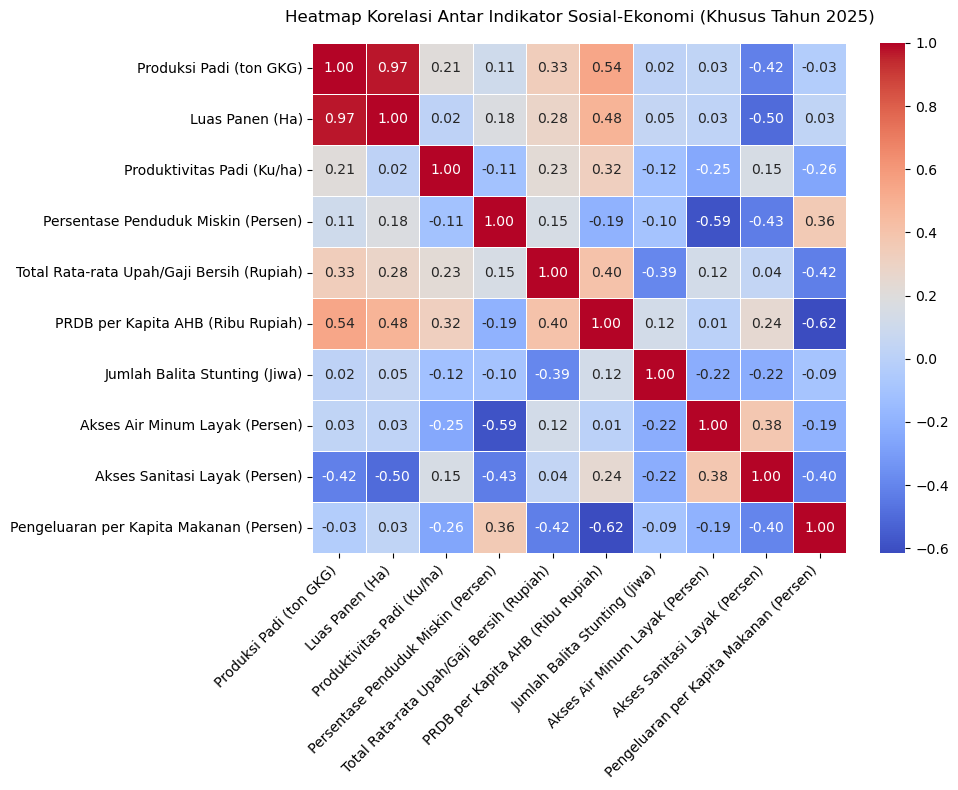

In [8]:
# Filter hanya kolom-kolom yang merupakan data tahun 2025
kolom_2025 = [col for col in df_scaled_features.columns if '_2025' in col]
df_korelasi_2025 = df_scaled_features[kolom_2025]

# Sederhanakan nama kolom agar rapi di Heatmap (menghilangkan teks "_2025")
df_korelasi_2025.columns = [col.replace('_2025', '') for col in df_korelasi_2025.columns]

# Hitung Matriks Korelasi
matriks_korelasi_2025 = df_korelasi_2025.corr()

# Gambar Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi_2025, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Heatmap Korelasi Antar Indikator Sosial-Ekonomi (Khusus Tahun 2025)', fontsize=12, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Eksplorasi Data Awal

Ringkasan Statistik Deskriptif Data Tahun 2025:
       Produksi Padi (ton GKG)  Luas Panen (Ha)  Produktivitas Padi (Ku/ha)  Persentase Penduduk Miskin (Persen)  Total Rata-rata Upah/Gaji Bersih (Rupiah)  PRDB per Kapita AHB (Ribu Rupiah)  Jumlah Balita Stunting (Jiwa)  Akses Air Minum Layak (Persen)  Akses Sanitasi Layak (Persen)  Pengeluaran per Kapita Makanan (Persen)
count                13.000000        13.000000                   13.000000                            13.000000                                  13.000000                          13.000000                      13.000000                       13.000000                      13.000000                                13.000000
mean                  0.426844         0.416222                    0.549975                             0.601160                                   0.460564                           0.384104                       0.230749                        0.652577                       0.505804                

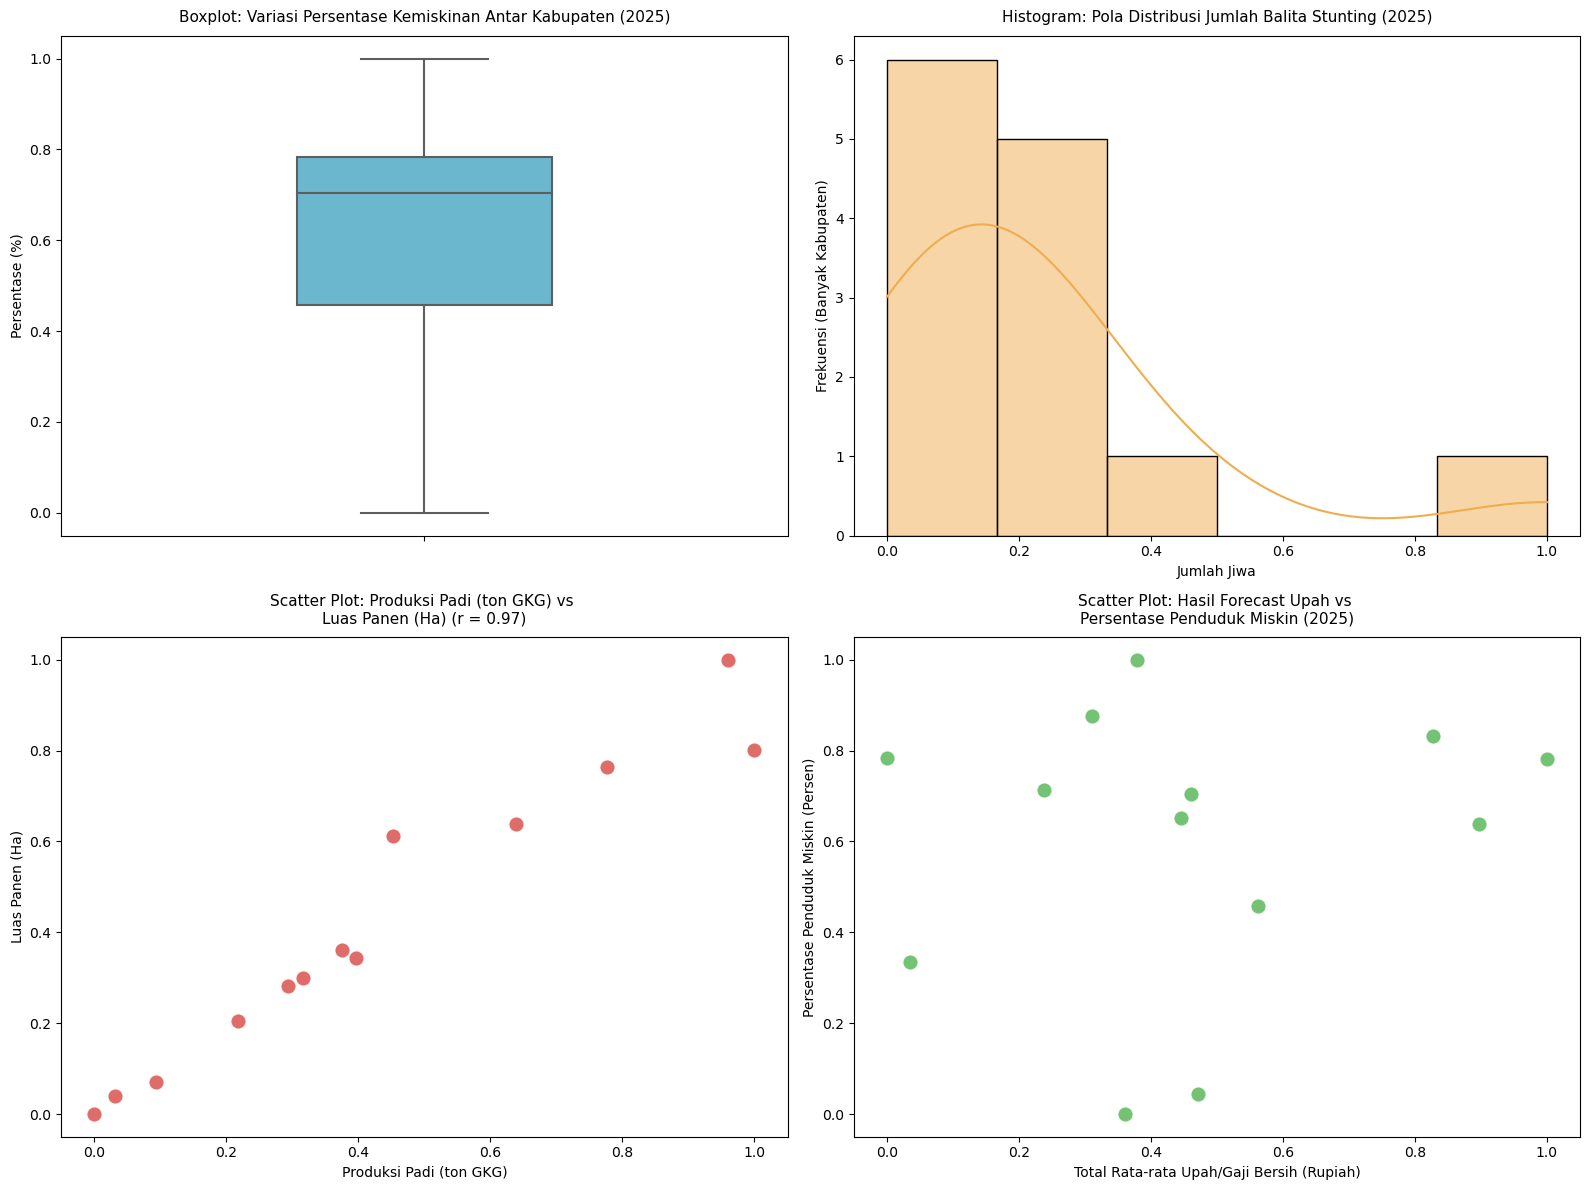

In [10]:
# Menampilkan Statistik Deskriptif (df.describe)
print("Ringkasan Statistik Deskriptif Data Tahun 2025:")
ringkasan_eda = df_korelasi_2025.describe()
print(ringkasan_eda.to_string())

# Penentuan Variabel untuk Scatter Plot (Berdasarkan Langkah 9)
matriks_korelasi_abs = matriks_korelasi_2025.abs()
# Mengosongkan diagonal utama agar tidak terpilih
np.fill_diagonal(matriks_korelasi_abs.values, 0)

# Mengambil pasangan dengan korelasi absolut tertinggi
pasangan_terkuat = matriks_korelasi_abs.unstack().idxmax()
var_x, var_y = pasangan_terkuat
nilai_korelasi_asli = matriks_korelasi_2025.loc[var_x, var_y]

print(f"Hasil Seleksi EDA:")
print(f"Hubungan terkuat ditemukan antara: '{var_x}' dan '{var_y}'")
print(f"Nilai Koefisien Korelasi (r): {nilai_korelasi_asli:.2f}")

# Membuat Grid EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

## BOXPLOT (Analisis Univariat: Sebaran & Outlier)
sns.boxplot(
    y=df_korelasi_2025['Persentase Penduduk Miskin (Persen)'],
    ax=axes[0, 0],
    color='#5bc0de',
    width=0.35
)
axes[0, 0].set_title('Boxplot: Variasi Persentase Kemiskinan Antar Kabupaten (2025)', fontsize=11, pad=10)
axes[0, 0].set_ylabel('Persentase (%)')

## HISTOGRAM (Analisis Univariat: Bentuk Distribusi)
sns.histplot(
    df_korelasi_2025['Jumlah Balita Stunting (Jiwa)'],
    kde=True,
    ax=axes[0, 1],
    color='#f0ad4e',
    bins=6
)
axes[0, 1].set_title('Histogram: Pola Distribusi Jumlah Balita Stunting (2025)', fontsize=11, pad=10)
axes[0, 1].set_xlabel('Jumlah Jiwa')
axes[0, 1].set_ylabel('Frekuensi (Banyak Kabupaten)')

## SCATTER PLOT 1 (Analisis Bivariat: Validasi Pasangan Terkuat)
sns.scatterplot(
    data=df_korelasi_2025,
    x=var_x,
    y=var_y,
    ax=axes[1, 0],
    color='#d9534f',
    s=120,
    alpha=0.85,
    edgecolor='w'
)
axes[1, 0].set_title(f'Scatter Plot: {var_x} vs \n{var_y} (r = {nilai_korelasi_asli:.2f})', fontsize=11, pad=10)

## SCATTER PLOT 2 (Analisis Bivariat: Hubungan Khusus Variabel Upah)
# Plot khusus untuk variabel upah hasil forecast
sns.scatterplot(
    data=df_korelasi_2025,
    x='Total Rata-rata Upah/Gaji Bersih (Rupiah)',
    y='Persentase Penduduk Miskin (Persen)',
    ax=axes[1, 1],
    color='#5cb85c',
    s=120,
    alpha=0.85,
    edgecolor='w'
)
axes[1, 1].set_title('Scatter Plot: Hasil Forecast Upah vs \nPersentase Penduduk Miskin (2025)', fontsize=11, pad=10)

# Menyinkronkan tata letak agar label dan judul tidak tumpang tindih
plt.tight_layout()
plt.show()